# Aprendizaje Estadístico y Data Mining

## Práctica 2: ¿Cómo son las cervezas artesanas?

### Objetivo
La misma empresa quiere encontrar una manera óptima de ordenar las cervezas para que los clientes puedan hacer unas búsquedas más eficientes en la tienda online. Para ello dispone de un set de datos de cervezas. Aplica un algoritmo de manera que se obtengan dichos grupos.

* [Link al dataset.](https://ufv-es.instructure.com/courses/42756/files/6155496/download?download_frd=1)

**Enunciado:** Realiza todo el preprocesamiento que sea necesario para adaptar las variables que no sean unívocas del dataset y poder usar el algoritmo adecuado.

**Solución**

Al empezar a trabajar con el dataset proporcionado para la práctica, nos encontramos con un problema común en muchos archivos de datos reales: el archivo CSV tiene un formato muy desordenado. Al intentar cargarlo con Python, descubrimos que muchas filas no tienen un formato uniforme. Esto se debe a que algunos campos, como las reseñas de usuarios (`review/text`) o las marcas de tiempo (`review/timeStruct`), contienen comas internas y estructuras complejas que no están correctamente delimitadas. Además, muchas filas incluyen columnas vacías innecesarias al final (como `;;;;;;;;;;;`) que contaminan la estructura esperada.

Antes de aplicar cualquier algoritmo de clustering, necesitamos que los datos estén bien estructurados. Esto implica que cada fila tenga el mismo número de columnas relevantes, que los campos de texto largos no se dividan por error, y que eliminemos cualquier ruido o información que no sea necesaria para el análisis (como datos del perfil del usuario). Si no realizamos esta limpieza previa, corremos el riesgo de que el código falle o de que los resultados del clustering sean inconsistentes o poco interpretables.

Para resolver este problema, optamos por una estrategia personalizada (a la cual nos costó llegar): leemos el archivo línea por línea como texto plano, eliminamos comillas y caracteres sobrantes, y extraemos solo las columnas relevantes para la práctica (`hasta review/timeUnix`). De forma estructurada, dividimos cada línea en tres bloques: los primeros 11 campos sencillos, el campo `review/text` que puede contener comas, y el campo `review/timeStruct`, que es un diccionario en forma de texto. Finalmente, extraemos el campo `review/timeUnix`.

Una vez extraídos los campos correctamente, validamos que la fila tenga las 14 columnas esperadas y descartamos aquellas que no cumplen. Por último, convertimos las columnas numéricas al tipo adecuado (`float o int`), transformamos `review/timeStruct` en un diccionario real para su posible análisis posterior, y almacenamos todas las filas válidas en un DataFrame limpio y consistente, listo para su uso en técnicas de clustering.

In [106]:
import ast
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [107]:
# Columnas necesarias para el DataFrame
# (Quitamos las relativas al usuario, por que no son necesarias
columnas = [
    'index','beer/ABV','beer/beerId','beer/brewerId','beer/name','beer/style',
    'review/appearance','review/aroma','review/overall','review/palate','review/taste',
    'review/text','review/timeStruct','review/timeUnix'
]

# Inicializar listas para almacenar filas que
# leamos del CSV y las que descartamos por error en el formato
filas = []
descartadas = []

# Abrimos el archivo CSV y lo leemos línea a línea
with open("data/cervezas.csv", "r", encoding="utf-8") as fichero:
    next(fichero) # Nos saltamos la cabecera

    # Para cada linea del fichero CSV
    for linea in fichero:
        try:
            # Eliminamos " y ; al final
            linea = linea.replace('"', '').replace(';', '').strip()

            # Paso 1: Extraemos los primeros 11 campos
            # (index, beer/ABV, beer/beerId, beer/brewerId, beer/name, beer/style,
            # review/appearance, review/aroma, review/overall, review/palate, review/taste)
            partes = linea.split(',', 11)
            if len(partes) != 12:
                descartadas.append(linea)
                continue

            primeros_11 = partes[:11]
            resto = partes[11]

            # Paso 2: Extraemos review/text y review/timeStruct
            if '{' not in resto or '}' not in resto:
                descartadas.append(linea)
                continue

            parte_texto_review, parte_struct_hora = resto.split('{', 1)
            texto_review = parte_texto_review.strip().rstrip(',')
            string_struct = '{' + parte_struct_hora.split('}', 1)[0] + '}'
            posterior_struct = parte_struct_hora.split('}', 1)[1].strip(',').split(',')

            # Paso 3: Extraemos review/timeUnix
            # (está después de review/timeStruct y es el primer campo después de la llave de cierre)
            if len(posterior_struct) == 0:
                descartadas.append(linea)
                continue

            time_unix = posterior_struct[0].strip()

            fila = primeros_11 + [texto_review, string_struct, time_unix]
            if len(fila) == len(columnas):
                filas.append(fila)
            else:
                descartadas.append(linea)

        except Exception:
            descartadas.append(linea)

# Creamos el DataFrame con las filas válidas
# y las columnas necesarias
df = pd.DataFrame(filas, columns=columnas)

# Convertimos las columnas a los tipos adecuados
columnas_numericas = [
    'beer/ABV','review/appearance','review/aroma','review/overall',
    'review/palate','review/taste','review/timeUnix'
]

# Limpiamos los espacios en blanco de las columnas de texto
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Convertimos las columnas numéricas a tipo float
# (si no se puede convertir, se convierte a NaN)
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convertimos review/timeStruct a diccionario
def parse_struct(val):
    try:
        return ast.literal_eval(val)
    except ValueError:
        return None

df['review/timeStruct'] = df['review/timeStruct'].apply(parse_struct)

# Resultado
print(f"Filas válidas cargadas: {len(df)}")
print(f"Filas descartadas: {len(descartadas)}")
display(df.head())


Filas válidas cargadas: 1431
Filas descartadas: 0


,index,beer/ABV,beer/beerId,beer/brewerId,beer/name,beer/style,review/appearance,review/aroma,review/overall,review/palate,review/taste,review/text,review/timeStruct,review/timeUnix
0,40163,5.0,46634,14338,Chiostro,Herbed / Spiced Beer,4.0,4.0,4.0,4.0,4.0,Pours a clouded gold with a thin white head. N...,"{'min': 38, 'hour': 3, 'mday': 16, 'sec': 10, ...",1229398690
1,8135,11.0,3003,395,Bearded Pat's Barleywine,American Barleywine,4.0,3.5,3.5,3.5,3.0,12oz bottle into 8oz snifter.\t\tDeep ruby red...,"{'min': 38, 'hour': 23, 'mday': 8, 'sec': 58, ...",1218238738
2,10529,4.7,961,365,Naughty Nellie's Ale,American Pale Ale (APA),3.5,4.0,3.5,3.5,3.5,First enjoyed at the brewpub about 2 years ago...,"{'min': 7, 'hour': 18, 'mday': 26, 'sec': 2, '...",1101492422
3,44610,4.4,429,1,Pilsner Urquell,Czech Pilsener,3.0,3.0,2.5,3.0,3.0,First thing I noticed after pouring from green...,"{'min': 7, 'hour': 1, 'mday': 20, 'sec': 5, 'y...",1308532025
4,37062,4.4,4904,1417,Black Sheep Ale (Special),English Pale Ale,4.0,3.0,3.0,3.5,2.5,A: pours an amber with a one finger head but o...,"{'min': 51, 'hour': 6, 'mday': 12, 'sec': 48, ...",1299912708


**Enunciado:** Utiliza varias configuraciones teniendo en cuenta el número de grupos que se creará y cambiando cómo se mide la distancia entre individuos. Crea una tabla donde se muestre una métrica válida para clustering y realiza un diagrama para elegir la mejor solución. ¿Cuál es?

**Solución**

El objetivo principal de este segundo punto de la práctica es determinar el número óptimo de grupos (clústers) en los que se pueden agrupar las cervezas artesanas en función de sus características sensoriales y de graduación alcohólica. Para ello, hemos utilizado el algoritmo K-Means, uno de los más comunes en problemas de segmentación no supervisada.

Antes de aplicar el algoritmo, seleccionamos únicamente las variables numéricas relevantes: `beer/ABV`, `review/appearance`, `review/aroma`, `review/overall`, `review/palate` y `review/taste`. Estas variables representan información cuantitativa objetiva o subjetiva relacionada con cada cerveza, y por tanto son aptas para calcular distancias entre muestras. Descartamos cualquier información del usuario, ya que no es relevante para los objetivos del enunciado.

Como cada variable tiene escalas diferentes (por ejemplo, `ABV` puede ir del 3 al 12%, mientras que `review/appearance` está en una escala del 0 al 5), es necesario escalarlas con p `StandardScaler`. Esto transforma todas las columnas para que tengan media 0 y desviación estándar 1, y así ninguna variable domina el cálculo de distancias del algoritmo K-Means.

Aplicamos K-Means con diferentes valores de k (de 2 a 10) para observar cómo varían la inercia (SSE) y la puntuación Silhouette, dos métricas clave:

* La inercia representa la suma de las distancias cuadradas de cada punto al centro de su clúster. Una menor inercia indica clústers más compactos.

* La puntuación de Silhouette mide la coherencia interna de los clústers: un valor más alto indica que los puntos están bien agrupados con su propio clúster y separados de los demás.

Creamos una tabla comparativa con estas métricas y dos gráficos de línea: uno para visualizar el "método del codo" (basado en la inercia) y otro para el índice de Silhouette, que ayuda a seleccionar el número óptimo de clústers.


Tabla de métricas de clustering:

    K      Inercia  Silhouette
0   2  5522.719644    0.333185
1   3  4295.936456    0.257555
2   4  3781.310587    0.200039
3   5  3366.990875    0.208698
4   6  3164.314190    0.185507
5   7  2988.304917    0.180655
6   8  2814.715018    0.182535
7   9  2692.563045    0.162271
8  10  2595.930710    0.160333


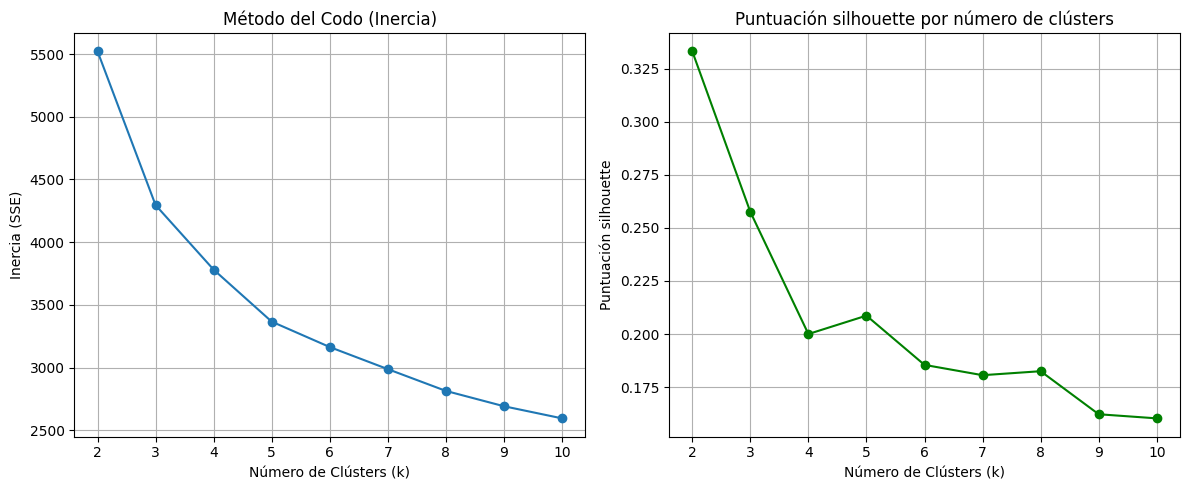


Mejor número de clústers según la puntuación de silhouette: k = 2


In [108]:
# 1. Definimos las columnas numéricas que usaremos para el clustering
columnas_numericas = ['beer/ABV','review/appearance','review/aroma','review/overall','review/palate','review/taste']
df_columnas_numericas = df[columnas_numericas].dropna().reset_index(drop=True)

# 2. Estandarizamos los datos
estandarizador = StandardScaler()
df_columnas_numerias_estandarizado = estandarizador.fit_transform(df_columnas_numericas)

# 3. Evaluamos diferentes valores de k
resultados = []
rangos_k = range(2, 11) # 2 a 10 clústers

for k in rangos_k:
    kmeans = KMeans(n_clusters=k, random_state=127, n_init=10)
    etiquetas = kmeans.fit_predict(df_columnas_numerias_estandarizado)
    inercia = kmeans.inertia_
    silhouette = silhouette_score(df_columnas_numerias_estandarizado, etiquetas)
    resultados.append({'K': k, 'Inercia': inercia, 'Silhouette': silhouette})

# 4. Creamos la tabla de resultados
tabla_resultados = pd.DataFrame(resultados)
print("\nTabla de métricas de clustering:\n")
print(tabla_resultados)

# 5. Dibujamos los gráficos: Método del Codo e Índice de Silhouette
plt.figure(figsize=(12, 5))

# Gráfico de la Inercia (SSE)
plt.subplot(1, 2, 1)
plt.plot(tabla_resultados['K'], tabla_resultados['Inercia'], marker='o')
plt.title("Método del Codo (Inercia)")
plt.xlabel("Número de Clústers (k)")
plt.ylabel("Inercia (SSE)")
plt.grid(True)

# Gráfico del Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(tabla_resultados['K'], tabla_resultados['Silhouette'], marker='o', color='green')
plt.title("Puntuación silhouette por número de clústers")
plt.xlabel("Número de Clústers (k)")
plt.ylabel("Puntuación silhouette")
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. Seleccionamos la mejor k según silhouette
mejor_k = tabla_resultados.loc[tabla_resultados['Silhouette'].idxmax(), 'K']
print(f"\nMejor número de clústers según la puntuación de silhouette: k = {mejor_k}")

Según los resultados obtenidos, el mejor valor de k es 2, ya que presenta la puntuación Silhouette más alta. Esto sugiere que las cervezas pueden agruparse de forma natural en dos grandes grupos claramente diferenciados. Este número de clústers también es interpretable desde una perspectiva práctica, lo cual es importante cuando se desea ofrecer una organización clara y útil para los clientes en una tienda online.

**Enunciado:** Con la mejor configuración del punto anterior. Dibuja un diagrama de líneas de los centroides. Interpreta como se comporta cada grupo y selecciona cuales son las variables más influyentes.

**Solución**

Una vez hemos identificado que la mejor configuración para el algoritmo K-Means era k = 2, procedimos a analizar el comportamiento de cada grupo generado por el algoritmo. Para ello, aplicamos de nuevo K-Means sobre los datos estandarizados, pero esta vez extrajimos y visualizamos los centroides de los clústers resultantes.

Un centroide representa el centro de un grupo o clúster: es el vector medio de todas las observaciones asignadas a ese grupo. Comparando los valores del centroide de cada grupo podemos entender cuáles son las características dominantes o diferenciadoras entre los distintos grupos de cervezas.

Vamos a utilizar un diagrama de líneas para representar los valores estandarizados de cada variable en ambos centroides. Esta visualización nos permitirá identificar de forma clara qué variables tienen mayores diferencias entre clústers, lo que indica cuáles influyen más en la segmentación.

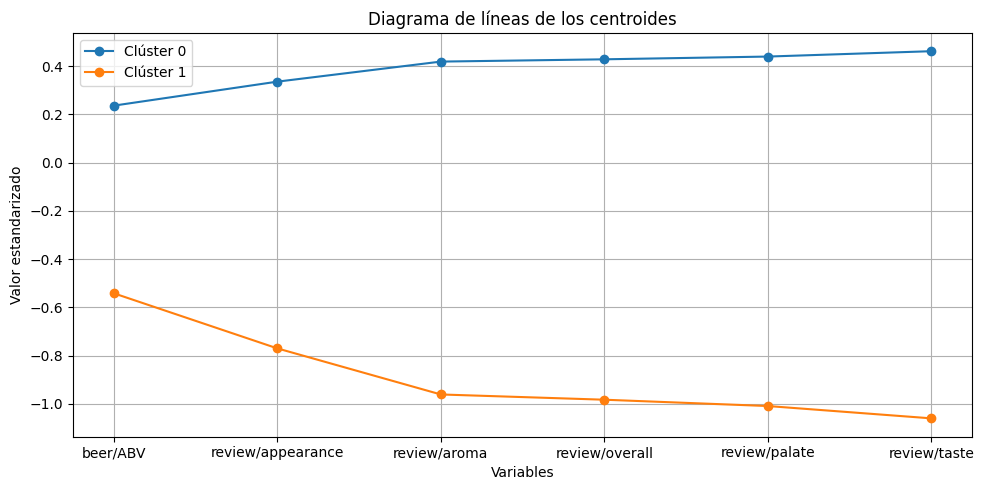


Variables más influyentes en la separación de clústers:
            Variable  Diferencia absoluta
5       review/taste             1.521496
4      review/palate             1.448160
3     review/overall             1.410558
2       review/aroma             1.379345
1  review/appearance             1.105288
0           beer/ABV             0.777607


In [109]:
# 1. Ejecutar K-Means con la mejor configuración (k = 2)
kmeans = KMeans(n_clusters=mejor_k, random_state=127, n_init=10)
kmeans.fit(df_columnas_numerias_estandarizado)

# 2. Obtener los centroides
centroides = kmeans.cluster_centers_

# 3. Dibujar los centroides
plt.figure(figsize=(10, 5))
for i, centroide in enumerate(centroides):
    plt.plot(columnas_numericas, centroide, marker='o', label=f'Clúster {i}')

plt.title('Diagrama de líneas de los centroides')
plt.xlabel('Variables')
plt.ylabel('Valor estandarizado')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Determinar las variables más influyentes
diferencias = pd.DataFrame({
    'Variable': columnas_numericas,
    'Diferencia absoluta': np.abs(centroides[0] - centroides[1])
}).sort_values(by='Diferencia absoluta', ascending=False)

# Mostrar tabla
print("\nVariables más influyentes en la separación de clústers:")
print(diferencias)


Los resultados nos muestran que las variables relacionadas con la experiencia del usuario (`review/taste`, `review/palate`, `review/overall`, `review/aroma`) son las que más contribuyen a separar los clústers. En otras palabras, las diferencias entre los grupos de cervezas se explican sobre todo por cómo son percibidas por los consumidores.

La variable `beer/ABV` (grado alcohólico) es la menos influyente de las seis, lo que sugiere que, aunque es una característica objetiva, no es tan determinante como otras variables a la hora de agrupar cervezas de forma natural según las valoraciones de los usuarios.

Este análisis justifica plenamente la utilidad del clustering para segmentar productos según la experiencia de consumo, y demuestra que el enfoque centrado en variables sensoriales es adecuado para este tipo de problema.

**Enunciado:** Teniendo en cuenta las dos variables más influyentes e inicializando los centroides de diferente manera, dibuja cómo se van modificando los grupos y cómo van cambiando sus centroides en cada iteración. Obtén una conclusión acerca de donde deberían situarse los centroides.

**Solución**

En este apartado, hemos explorado el comportamiento dinámico del algoritmo K-Means cuando se aplica únicamente sobre las dos variables más influyentes identificadas en el punto anterior: review/taste y review/palate. Estas variables representan el sabor y la sensación en boca de cada cerveza, y son claves en la percepción del consumidor.

Con el objetivo de observar cómo evolucionan los centroides del algoritmo, inicializamos manualmente K-Means con dos centroides aleatorios tomados directamente del dataset estandarizado. A diferencia de una ejecución habitual donde el algoritmo converge internamente, en este caso forzamos una iteración por llamada (max_iter=1) y repetimos el proceso cinco veces para registrar los cambios manualmente.

Esta estrategia nos permite visualizar, paso a paso, cómo los centroides se ajustan progresivamente a la estructura natural de los datos.

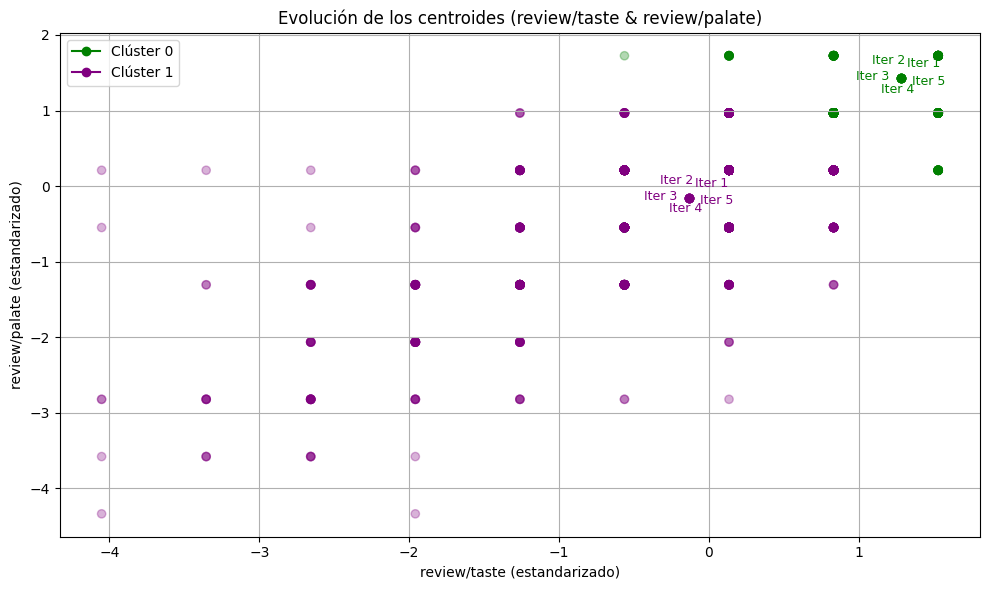

In [110]:
# Seleccionamos las 2 variables más influyentes
variables_influyentes = df[['review/taste', 'review/palate']].dropna()
variables_influyentes_estandarizadas = estandarizador.fit_transform(variables_influyentes)

np.random.seed(127)

# Inicializar KMeans con 2 clústers y centroides iniciales aleatorios
# (se eligen 2 puntos aleatorios del dataset estandarizado)
indices = np.random.choice(len(variables_influyentes_estandarizadas), size=2, replace=False)
centroides_iniciales = variables_influyentes_estandarizadas[indices]

# Ejecutamos KMeans con los centroides iniciales
evolucion_centroides = []
evolucion_etiquetas = []

kmeans = KMeans(n_clusters=mejor_k, init=centroides_iniciales, n_init=1, max_iter=1, random_state=127)

# Vamos a hacer 5 iteraciones para observar
# la evolución de los centroides
for iteracion in range(5):
    kmeans.fit(variables_influyentes_estandarizadas)
    evolucion_centroides.append(kmeans.cluster_centers_.copy())
    evolucion_etiquetas.append(kmeans.labels_)


# Dibujamos la evolución de los centroides
plt.figure(figsize=(10, 6))
colores = ['green', 'purple']

# Trazamos la trayectoria de cada centroide
for i in range(2):
    trayectoria = np.array([c[i] for c in evolucion_centroides])

    plt.plot(trayectoria[:, 0], trayectoria[:, 1], marker='o', color=colores[i], label=f'Clúster {i}')

    for j, punto in enumerate(trayectoria):
        angulo_etiqueta = 2 * math.pi * j / len(trayectoria) + math.pi/4
        radio = 0.2
        dx = radio * math.cos(angulo_etiqueta)
        dy = radio * math.sin(angulo_etiqueta)

        plt.text(punto[0] + dx - 0.1 , punto[1] + dy, f'Iter {j+1}', fontsize=9, color=colores[i])

# Trazar los puntos según asignación final
etiquetas_finales = evolucion_etiquetas[-1]
plt.scatter(variables_influyentes_estandarizadas[:, 0], variables_influyentes_estandarizadas[:, 1], c=[colores[label] for label in etiquetas_finales], alpha=0.3)

# Ajustes del gráfico
plt.title('Evolución de los centroides (review/taste & review/palate)')
plt.xlabel('review/taste (estandarizado)')
plt.ylabel('review/palate (estandarizado)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

En el gráfico que hemos creado, cada línea representa la trayectoria de un centroide a lo largo de las iteraciones, y cada etiqueta `Iter x` muestra su posición en una iteración concreta. Las etiquetas las hemos distribuido alrededor del punto en un patrón circular para evitar solapamientos, lo que mejora la claridad visual del proceso.

También representamos los datos con colores según la asignación final de clústers, lo que nos permite entender cómo se han repartido los puntos tras la convergencia.

Observamos que los centroides convergen rápidamente: ya en las primeras iteraciones alcanzan posiciones cercanas a su ubicación final. Esto sugiere que los datos tienen una estructura clara y bien separada, lo que permite al algoritmo de K-Means agrupar las observaciones de manera estable y eficiente con muy pocas iteraciones.

Podemos concluir que los centroides deberían situarse en zonas donde:

* Se concentran observaciones con altas valoraciones sensoriales en taste y palate.

* Se maximice la distancia a puntos del otro grupo, lo que optimiza la cohesión interna y la separación entre grupos.

Este tipo de visualización es muy útil para entender el proceso interno de optimización de K-Means, especialmente cuando se utilizan variables clave como taste y palate en productos como las cervezas artesanas.

**Enunciado:** Estudia que técnicas de postprocesamiento (variables que no aportan nada, outliers, etc) se podrían aplicar en base al error cometido en cada clúster.

**Solución**

En este último apartado, hemos analizado el desempeño del modelo de clustering tras aplicar el algoritmo K-Means sobre las dos variables más influyentes detectadas anteriormente: `review/taste` y `review/palate`. El objetivo de este análisis ha sido evaluar la calidad interna de los grupos generados por el algoritmo y detectar observaciones que pudieran comportarse como outliers, es decir, puntos significativamente alejados de sus respectivos centros de clúster.

Para llevar a cabo esta evaluación, primero entrenamos de nuevo un modelo de K-Means con k=2, utilizando las variables estandarizadas mencionadas. A continuación, calculamos la distancia de cada muestra al centroide de su clúster asignado. Esta distancia representa el “error” de agrupamiento individual de cada punto, entendiendo que una distancia pequeña implica que el punto está bien ubicado dentro de su grupo, mientras que una distancia elevada sugiere que se aleja del centro del grupo y podría estar mal clasificado. Este valor los incorporamos como una nueva columna (`error_distancia`)` en el dataframe original.

Posteriormente, representamos gráficamente la distribución de estas distancias mediante un histograma, separado por clúster.

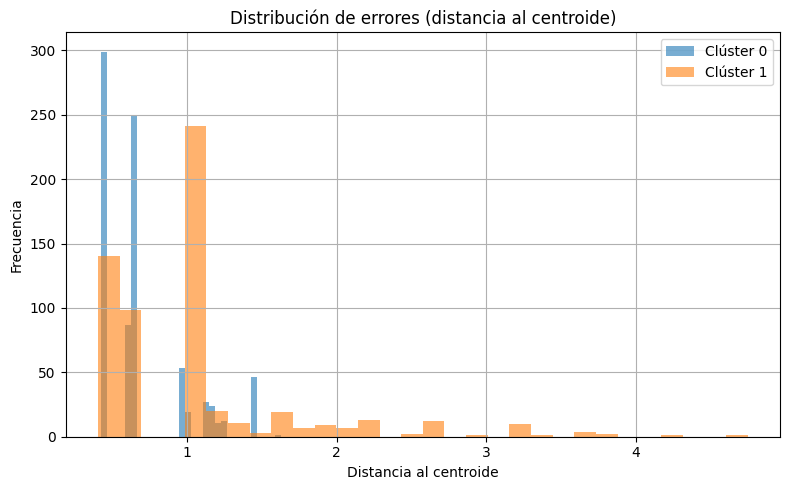

Posibles Outliers según error al centroide (total: 70)


,review/taste,review/palate,cluster,error_distancia
9,2.0,2.5,1,2.185841
13,2.0,2.5,1,2.185841
45,1.5,4.0,1,2.713566
87,3.0,4.5,1,1.847570
107,2.0,1.5,1,3.286582
118,1.0,1.0,1,4.746343
125,3.0,2.0,1,2.029599
128,2.0,2.0,1,2.686191
143,1.5,3.0,1,2.549011
151,2.0,3.0,1,1.867744


Mostrando 10 de 70 outliers detectados


In [113]:
# Aplicamos K-means a las variables influyentes para obtener las etiquetas correctas
kmeans_influyentes = KMeans(n_clusters=mejor_k, random_state=127, n_init=1)
etiquetas = kmeans_influyentes.fit_predict(variables_influyentes_estandarizadas)
centroides_influyentes = kmeans_influyentes.cluster_centers_

# Calculamos los errores (distancias al centroide correspondiente)
errores = np.linalg.norm(variables_influyentes_estandarizadas - centroides_influyentes[etiquetas], axis=1)

# 1. Agregamos la información al DataFrame original
df_post = variables_influyentes.copy()
df_post['cluster'] = etiquetas
df_post['error_distancia'] = errores

# 2. Visualizamos la distribución de errores por clúster
plt.figure(figsize=(8, 5))
for cl in sorted(df_post['cluster'].unique()):
    plt.hist(df_post[df_post['cluster'] == cl]['error_distancia'], bins=30, alpha=0.6, label=f'Clúster {cl}')
plt.title('Distribución de errores (distancia al centroide)')
plt.xlabel('Distancia al centroide')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Detectamos posibles outliers: error por encima del percentil 95
umbral_outlier = np.percentile(df_post['error_distancia'], 95)
outliers = df_post[df_post['error_distancia'] > umbral_outlier]

# 4. Mostramos tabla de outliers
print(f"Posibles Outliers según error al centroide (total: {len(outliers)})")
display(outliers.head(10))
print(f"Mostrando 10 de {len(outliers)} outliers detectados")

En el gráfico, observamos que la mayoría de los puntos presentan errores bajos, lo cual nos indica que, en general, los clústers son compactos y bien definidos. Sin embargo, también se aprecia la existencia de una “cola” hacia la derecha, es decir, un grupo reducido de observaciones con errores significativamente altos. Estas observaciones, por su lejanía al centroide, pueden ser consideradas potenciales outliers.

A partir de este análisis, se hemos extraido algunas conclusiones importantes. Por un lado, las observaciones con error superior al percentil 95 pueden representar cervezas con valoraciones atípicas o inconsistentes respecto al resto, por lo que es recomendable revisarlas o incluso eliminarlas si se desea mejorar la precisión y estabilidad del modelo. Por otro lado, eliminar estos outliers y volver a aplicar el algoritmo de clustering podría derivar en clústers más homogéneos, lo que podría reflejarse en una mejora de la puntuación Silhouette  o en una separación más clara entre grupos. Finalmente, aunque en este análisis sólo trabajamos con las variables más influyentes, creemos que se podría realizar en el futuro una revisión adicional del resto de variables utilizadas en el modelo original para evaluar si alguna de ellas no aporta información relevante o incluso introduce ruido. Para ello, podríamos emplear técnicas como el análisis de correlación, la importancia de características o métodos de reducción de dimensionalidad como PCA.